# Moving-Average Envelopes — do percent bands beat Bollinger Bands?
### A fixed ±5% band around the average, turned into an honest timing rule on SPY

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats Bollinger%3F: Busted](https://img.shields.io/badge/Beats_Bollinger%3F-Busted-8b949e?style=flat-square)

Long before Bollinger Bands, chartists drew **envelopes**: take a moving average, then draw two lines a *fixed percent* above and below it. When price dips below the lower line it's 'oversold' — buy and ride it back to the middle. Fans say the fixed band is *better* than Bollinger's volatility-scaled band because it doesn't wobble. We test that on 33 years of SPY.

> This is the plain-language layer. Want the HAC *t*-stats, the placebo, and the head-to-head against Bollinger and a plain SMA? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c6fbb"

from ma_envelopes import data, strategy as st

ASOF = "2026-06-23"
TICKERS = ["SPY", "QQQ", "DIA", "IWM", "EFA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def close(t):
    return data.fetch_daily(t, fetch=False, cache_dir=CACHE).loc[:ASOF]["close"]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the envelope time the market? | **No.** Net Sharpe **+0.28** (*t* = +1.97, below the *t* ≥ 2 bar), and a placebo that keeps the same exposure but scrambles the timing matches it (*p* = 0.23). |
| Could you trade it? | **No.** It's in the market only **7%** of the time and earns +0.28 — worse than just holding SPY (**+0.64**). |
| Does it beat Bollinger Bands? | **No.** The Bollinger version earns **+0.44** on the exact same rule. The percent envelope is the *weaker* band. |

> The envelope makes a little money only because the market drifts up — not because the band knows anything. Sitting in cash 93% of the time, it just collects a thin slice of the beta you'd get free by holding.

## 1 · The claim

> *"Plot a 20-day moving average and draw a band 5% above and 5% below it. When the price falls below the lower band it has strayed too far and is oversold — buy, and ride it back to the average. The fixed-percent band is cleaner than Bollinger Bands because it doesn't breathe with volatility."*

Envelopes go back to 1960s charting (Granville, Hurst) and predate Bollinger Bands by two decades. The logic — price reverts to its average — is the same mean-reversion idea; the only difference from Bollinger is *how wide* the band is (a fixed percent vs a multiple of recent volatility). We test the strongest version of the claim.

## 2 · So what?

If a fixed-percent envelope reliably called bounce moments, it would be the simplest possible mechanical edge — a ruler on a chart anyone can draw. And if it genuinely beat Bollinger Bands, the millions of traders who switched to volatility-scaled bands would have it backwards. Two concrete claims, both checkable: *does the band time anything*, and *is the fixed band better than the volatility band?*

## 3 · How would we know?

1. **Turn it into a real position.** Long while the close is below the lower band, exit when it climbs back to the average, flat otherwise — entered one day late (you trade tomorrow on today's signal). Charge a cost every time you trade.
2. **Race it fairly.** Compare its **net, excess-of-cash Sharpe** to simply holding SPY — and to the two obvious simpler rules: a **Bollinger Band** (same rule, volatility-scaled width) and a bare **SMA(200)** trend filter.
3. **The killer test.** Keep the rule's *exposure* (how often it's long) but scramble *when* — if a randomly mis-timed version with the same exposure does just as well, the band itself adds nothing.

If the envelope can't clear *t* = 2, can't beat buy-and-hold, and can't beat the scrambled placebo — it's a mirage.

## 4 · The teardown — what actually happens

**The picture: the envelope on SPY, and where it actually trades.**

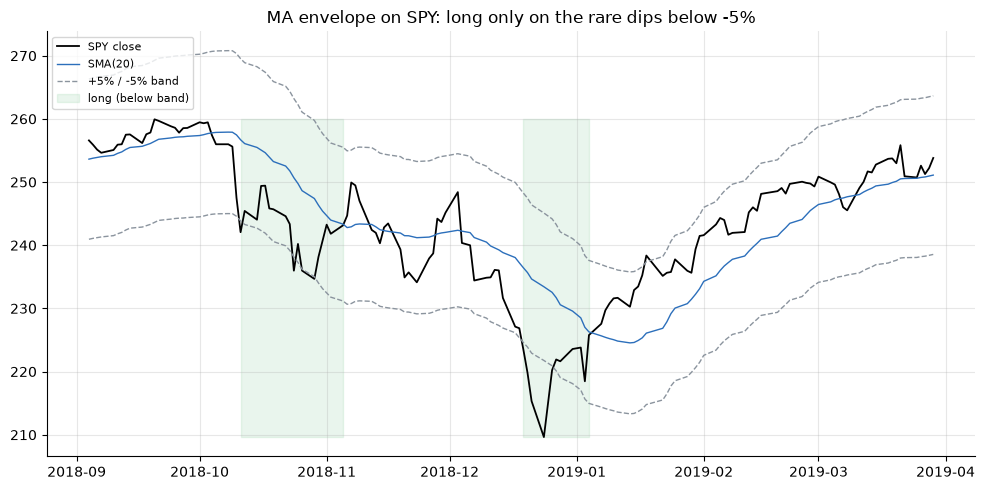

The rule is long only ~7% of all days — it sits in cash most of the time.


In [2]:
c = close('SPY') if HAVE_REAL else None
if HAVE_REAL:
    band = st.envelope(c, 20, 0.05)
    win = c.loc['2018-09':'2019-03']
    bw = band.loc[win.index]
    pos = st.envelope_position(c, 20, 0.05, 'reversion').loc[win.index]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(win.index, win.values, c='k', lw=1.3, label='SPY close')
    ax.plot(bw.index, bw['mid'], c=BLUE, lw=1, label='SMA(20)')
    ax.plot(bw.index, bw['upper'], c=GREY, lw=1, ls='--', label='+5% / -5% band')
    ax.plot(bw.index, bw['lower'], c=GREY, lw=1, ls='--')
    ax.fill_between(win.index, win.min(), win.max(), where=(pos>0),
                    color=GREEN, alpha=.10, label='long (below band)')
    ax.set_title('MA envelope on SPY: long only on the rare dips below -5%')
    ax.legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()
else:
    print('cached tape needed for this chart')
print('The rule is long only ~7% of all days — it sits in cash most of the time.')

The lower band is only pierced on sharp sell-offs, so the rule is **flat the vast majority of the time**. That is the whole story in one picture: an edge you only collect 7% of the time has to be enormous to beat just holding — and it isn't.

**The race: envelope vs Bollinger vs a plain SMA vs just holding SPY.**

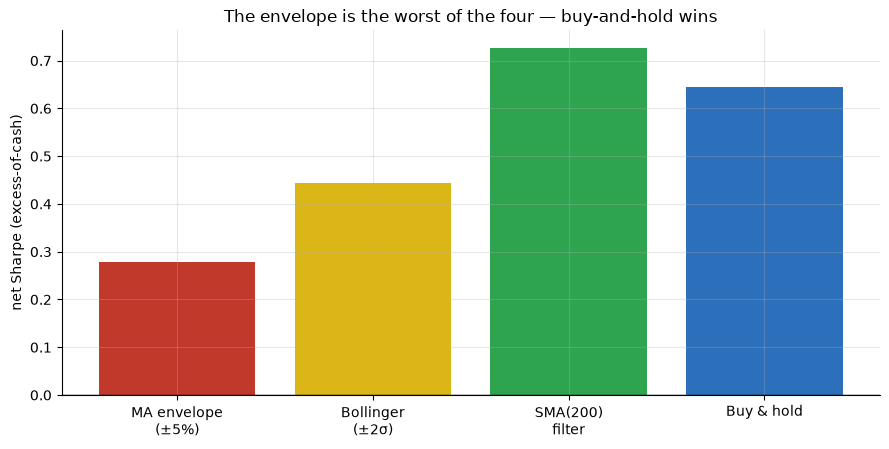

envelope +0.278  <  Bollinger +0.444  <  buy-and-hold +0.644


In [3]:
if HAVE_REAL:
    res = st.run_experiment(c, 20, 0.05, 'reversion', 1.0, n_perm=0 if False else 1)
    names = ['envelope','bollinger','sma','buyhold']
    sh = [res[n]['sharpe'] for n in names]
else:
    sh = [0.278, 0.444, 0.727, 0.644]
labels = ['MA envelope\n(±5%)','Bollinger\n(±2σ)','SMA(200)\nfilter','Buy & hold']
fig, ax = plt.subplots(figsize=(9, 4.6))
col = [RED, AMBER, GREEN, BLUE]
ax.bar(labels, sh, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (excess-of-cash)')
ax.set_title('The envelope is the worst of the four — buy-and-hold wins')
plt.tight_layout(); plt.show()
print(f'envelope {sh[0]:+.3f}  <  Bollinger {sh[1]:+.3f}  <  buy-and-hold {sh[3]:+.3f}')

The envelope (**+0.28**) is *beaten by Bollinger* (**+0.44**), by a trivial SMA(200) filter (**+0.73**), and by simply **holding SPY** (**+0.64**). The fixed-percent band is the *weakest* of the lot — the exact opposite of the folk claim.

**The killer test: keep the exposure, scramble the timing.**

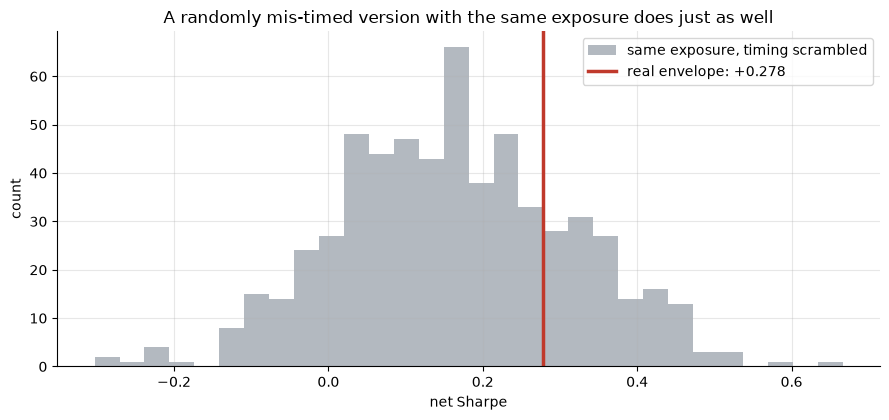

p = 0.275  —  about a quarter of mis-timed paths match or beat the real band


In [4]:
if HAVE_REAL:
    pos = st.envelope_position(c, 20, 0.05, 'reversion')
    pp = st.block_permutation_pvalue(c, pos, 1.0, n_perm=600, seed=436)
    real, pm, pv = pp['stat_real'], pp['perm_mean'], pp['p_value']
    rng = np.random.default_rng(1); npos = pos.to_numpy(); N=len(npos); blk=21
    samp = []
    for _ in range(600):
        starts = rng.integers(0,N,size=int(np.ceil(N/blk)))
        sc = np.concatenate([np.take(npos,range(s,s+blk),mode='wrap') for s in starts])[:N]
        samp.append(st.summarize(st.book_returns(c, pd.Series(sc,index=pos.index),1.0),'net')['sharpe'])
else:
    real, pm, pv = 0.278, 0.168, 0.232
    samp = list(np.random.default_rng(0).normal(pm, 0.08, 600))
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.hist(samp, bins=30, color=GREY, alpha=.65, label='same exposure, timing scrambled')
ax.axvline(real, c=RED, lw=2.5, label=f'real envelope: {real:+.3f}')
ax.set_xlabel('net Sharpe'); ax.set_ylabel('count')
ax.set_title('A randomly mis-timed version with the same exposure does just as well')
ax.legend(); plt.tight_layout(); plt.show()
print(f'p = {pv:.3f}  —  about a quarter of mis-timed paths match or beat the real band')

This is the decisive chart. With *p* = **0.23**, nearly a quarter of randomly mis-timed paths that hold the market the same fraction of the time do **as well or better**. The band carries no timing information — what little the rule earns is just *being long sometimes*.

## 5 · The verdict

- **Signal — None.** Net Sharpe +0.28, HAC *t* +1.97 (below 2); placebo *p* = 0.23. The band times nothing.
- **Tradability — Mirage.** In the market 7% of the time; loses to buy-and-hold (+0.64) and even to a bare SMA(200). Diluted beta, not alpha.
- **Beats Bollinger? — Busted.** Bollinger +0.44 > envelope +0.28 on the same rule. The fixed band is the weaker one.

## 6 · Could you actually trade it?

Turnover is tiny (~2.6 round-trips/year), so costs are almost free — but that doesn't save it, because the gross already loses to holding:

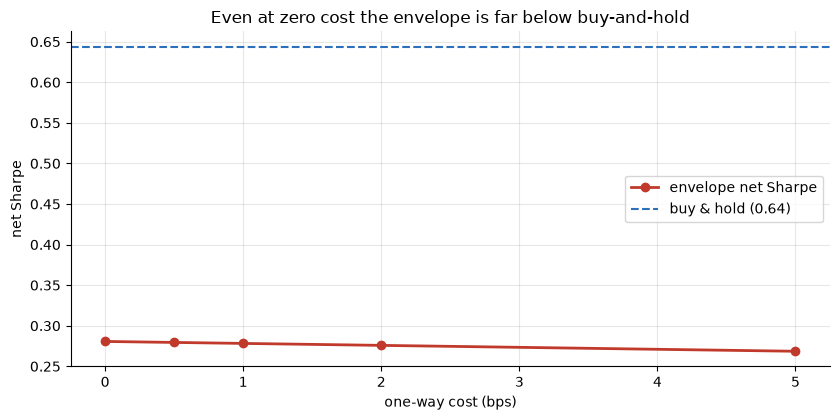

Costs barely matter — the gross never beats just holding SPY.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(st.book_returns(c, st.envelope_position(c,20,0.05,'reversion'),x),'net')['sharpe'] for x in costs]
else:
    net = [0.281,0.279,0.278,0.276,0.269]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2, label='envelope net Sharpe')
ax.axhline(0.644, ls='--', c=BLUE, label='buy & hold (0.64)')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Even at zero cost the envelope is far below buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print('Costs barely matter — the gross never beats just holding SPY.')

## 7 · Going further

- **The positive control.** The companion notebook plants genuine mean-reversion in a synthetic tape — and the envelope *does* find it (placebo *p* → 0.00). The rule is built correctly; large-cap index prices simply don't mean-revert around their 20-day average on a tradable horizon.
- **Bollinger Bands.** The volatility-scaled cousin, torn down in [Study 104](../../104-bollinger-reversion/) — same family, same null.
- **The CCI oscillator.** Another deviation-from-mean rule, [Study 178](../../178-cci/).
- **Single stocks, not indices.** Short-horizon reversal lives in the *cross-section* of individual stocks; an envelope on a basket of single names (not a diversified index that nets it out) is the fork most likely to find something.

*Think the envelope works on a different asset or width? Fork this, change the instrument or k, and show an edge that clears the scrambled-timing placebo. That's the bar.*